In [1]:
from bpe import BPETokenizer, normalize

### Task 1: Prepare the data and tokens (15 points)

1. Split the corpus into the training, validation and test sets, as described above. Print the number

Justification: We use an 80/10/10 split because it provides enough data for training while keeping separate validation and test sets for model selection and final evaluation.

In [2]:
import pathlib
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
local_path = pathlib.Path("data/shakespeare.txt")

if local_path.exists():
    text = local_path.read_text(encoding="utf-8")
else:
    response = requests.get(url)
    response.encoding = "utf-8"
    text = response.text

# Split text into lines
lines = text.splitlines()

# marking position in lines where training, validation and testing ends
train_end = int(len(lines) * 0.8)
val_end = int(len(lines) * 0.9)

# creating each set
train_lines = lines[:train_end]
val_lines = lines[train_end:val_end]
test_lines = lines[val_end:]

# # Join the lines back into text strings to count the characters in each split
train_text = "\n".join(train_lines)
val_text = "\n".join(val_lines)
test_text = "\n".join(test_lines)

# Print number of lines
print("Number of train lines:", len(train_lines))
print("Number of validation lines:", len(val_lines))
print("Number of test lines:", len(test_lines))

# Print number of characters
print("Number of train characters:", len(train_text))
print("Number of validation characters:", len(val_text))
print("Number of test characters:", len(test_text))

Number of train lines: 32000
Number of validation lines: 4000
Number of test lines: 4000
Number of train characters: 907167
Number of validation characters: 109073
Number of test characters: 99151


2. Train a BPE tokenizer on the training set. Any reasonable value of k is fine for now; you search over k in Task 4.

In [3]:
strategy = "clean"

tok = BPETokenizer(
    num_merges=1000,
    end_of_word="</w>",
    strategy=strategy
)

# Normalize training text with the same strategy
train_text_normalized = normalize(train_text, strategy)

# Train BPE only on the training split
tok.train(train_text_normalized)


print("merges:", len(tok.merges))
print("Vocabulary size:", len(tok.vocab))

merges: 1000
Vocabulary size: 1039


3. Encode all three splits as sequences of token ids, with <bos> and <eos>.

In [4]:
# code correction
tok.vocab.pop("<bos>", None)
tok.vocab.pop("<eos>", None)

# addinc tokens to vocabulary
tok.vocab["<bos>"] = len(tok.vocab)
tok.vocab["<eos>"] = len(tok.vocab)

# storing ids in variables
bos_id = tok.vocab["<bos>"]
eos_id = tok.vocab["<eos>"]

# using trigram
n = 3

# Encode every training line with the BPE tokenizer
# and add n-1 <bos> tokens at the beginning and one <eos> token at the end -> we need context for a trigram also for the first word
train_ids = [
    [bos_id] * (n - 1)
    + tok.encode(line, count_unk=False)
    + [eos_id]
    for line in train_lines
]

# same for the validation split
val_ids = [
    [bos_id] * (n - 1)
    + tok.encode(line, count_unk=False)
    + [eos_id]
    for line in val_lines
]

# same for the test split
test_ids = [
    [bos_id] * (n - 1)
    + tok.encode(line, count_unk=False)
    + [eos_id]
    for line in test_lines
]

# Check the IDs of the special tokens
print("BOS ID:", bos_id)
print("EOS ID:", eos_id)

# example sequence
print("\nFirst training sequence:")
print(train_ids[0])

# Check that each original line produced one encoded sequence
print("\nNumber of training sequences:", len(train_ids))
print("Number of validation sequences:", len(val_ids))
print("Number of test sequences:", len(test_ids))

BOS ID: 1039
EOS ID: 1040

First training sequence:
[1039, 1039, 376, 806, 1040]

Number of training sequences: 32000
Number of validation sequences: 4000
Number of test sequences: 4000


4. Print the number of tokens in the validation split and the test split that map to <unk>. This number should be small.

In [5]:
# Get the token ID of <unk>
unk_id = tok.vocab["<unk>"]

# Count <unk> tokens in validation and test sequences
val_unk_count = sum(sequence.count(unk_id) for sequence in val_ids)
test_unk_count = sum(sequence.count(unk_id) for sequence in test_ids)

print("unk in validation:", val_unk_count)
print("unk in test:", test_unk_count)

unk in validation: 0
unk in test: 0


### Task 2: The n-gram engine (30 points)

Write a class NGramLM. It takes the order n and the vocabulary size V .
1. fit(sequences) counts every n-gram and every (n − 1)-gram in the training sequences. Keep the counts in dictionaries.

2. log_prob(token, context) returns log P (token | context). The context is the list of the previous n − 1 tokens. 
Use add-one smoothing: P (w | h) = c(h, w) + 1
c(h) + V
Here c(h, w) is the count of the n-gram and c(h) is the count of its history. Apply this formula to every token, also to tokens that the model has seen. Do not add a special case for a zero count.

3. next_token_log_probs(context) returns a numpy array with one entry for each token id in the vocabulary. The exponentials of the entries must sum to 1.

In [6]:
import math
import numpy as np

from ngram import NGramLM

In [7]:
# Create and train trigram model
lm = NGramLM(
    n=3,
    vocab_size=len(tok.vocab)
)

lm.fit(train_ids)

# Example context
context = [bos_id, bos_id]

# calculating log probabilities
log_probs = lm.next_token_log_probs(context)

# Convert log probabilities to standard probabilities
probs = np.exp(log_probs)

print("Number of probabilities:", len(probs))
print("Sum of probabilities:", probs.sum())

Number of probabilities: 1041
Sum of probabilities: 1.0


4. A token in the context that never appears in the training counts gets no history count. Give it the average unigram probability, which is 1/V . Say in the notebook how you handle this case.

If a context was never seen during training, its context count is 0. With smoothing, the probability is automatically (0 + 1) / (0 + V) = 1 / V. No separate special case is needed.

In [8]:
unigram_lm = NGramLM(
    n=1,
    vocab_size=4
)

unigram_sequences = [
    [0, 1, 2],
    [1, 2, 3]
]

unigram_lm.fit(unigram_sequences) # training the n gram

log_p = unigram_lm.log_prob(1, []) # log probability given no context

print("Log probability:", log_p)
print("Probability:", math.exp(log_p))

log_probs = unigram_lm.next_token_log_probs([])
print("Sum:", np.exp(log_probs).sum()) # making normal probabilities

Log probability: -1.2039728043259361
Probability: 0.3
Sum: 1.0


5. For n = 1 the context is empty. The class must still work.
Check your engine on a toy corpus of five short sequences before you use the real data. Compute two probabilities by hand and compare them against the code

In [9]:
# test corpus
test_sequences = [
    [0, 1, 3],
    [0, 1, 3],
    [0, 2, 3],
    [0, 1, 2, 3],
    [0, 2, 3]
]

test_lm = NGramLM(
    n=2,
    vocab_size=4
)

test_lm.fit(test_sequences) # training

p1_code = math.exp(test_lm.log_prob(1, [0])) # getting probabilities
p2_code = math.exp(test_lm.log_prob(3, [1]))

p1_hand = (3 + 1) / (5 + 4) # by hand calculation
p2_hand = (2 + 1) / (3 + 4)

print("P(1 | 0)")
print("Hand:", p1_hand)
print("Code:", p1_code)

print()

print("P(3 | 1)")
print("Hand:", p2_hand)
print("Code:", p2_code)

P(1 | 0)
Hand: 0.4444444444444444
Code: 0.4444444444444444

P(3 | 1)
Hand: 0.42857142857142855
Code: 0.42857142857142855


### Task 3: Perplexity (15 points)

Write a function perplexity(model, sequences). It takes any model with a log_prob method.
It returns:

$$
\mathrm{PP}
=
\exp\left(
-\frac{1}{N}
\sum_{i=1}^{N}
\log P(w_i \mid h_i)
\right)
$$

Here N counts every predicted token, including <eos>. It does not count <bos>, because the model
does not predict <bos>. Sum the log probabilities. Do not multiply the probabilities.
Also return the perplexity per character:

$$
\mathrm{PP}_{\mathrm{char}}
=
\exp\left(
-\frac{1}{C}
\sum_{i=1}^{N}
\log P(w_i \mid h_i)
\right)
$$

Here C is the number of characters in the original text. The two values answer different questions.
The perplexity per token depends on k, because a larger k gives longer tokens. The perplexity per
character does not. Use the second value whenever you compare across k

In [10]:
from evaluation import perplexity

**Sanity check**. Compute the perplexity of the unigram model on its own training data. Then
compute it on a file of 200 random token ids. Explain the two numbers in one sentence each.

In [11]:
# Vocabulary size for the unigram model
V = len(tok.vocab)

# Train unigram model on the real training data
unigram = NGramLM(
    n=1,
    vocab_size=V
)

unigram.fit(train_ids)

print("Unigram vocabulary size:", V)

Unigram vocabulary size: 1041


In [12]:
# Perplexity on training data
pp_train = perplexity(unigram, train_ids)

print("Training PP:", pp_train)

Training PP: 233.2637615013991


In [13]:
rng = np.random.default_rng(42)

random_ids = [[
    int(x)
    for x in rng.integers(
        0,
        V,
        size=200
    )
]]

pp_random = perplexity(unigram, random_ids)

print("Random PP:", pp_random)

Random PP: 2403.9168233187884


Perplexity can be interpreted as a measure of how "suprised" the model is.

Training PP = 233.26: Since the unigram has learned the frequency distribution of BPE tokens, it is not very "perplexed" by the data it is given, therefore the perplexity is quite low.

Random PP = 2403.92: For the random data the model has no chance of knowing which tokens come next. Therefore the perplexity very high.

### Task 4: Model selection on the validation set (20 points)

Use the tool from Task 3 to choose the order n and the vocabulary size k.

1. For k ∈ {250, 500, 1000, 2000, 4000}, train a BPE tokenizer on the training split. For each k,
encode the training split and the validation split.

2. For each k and for n ∈ {1, 2, 3}, train an NGramLM with add-one smoothing on the training
tokens. This gives 15 models.

3. Compute the perplexity per character of every model on the validation set. Report the full grid
as one table, with n in the rows and k in the columns.

4. Plot the perplexity per character against k, with one line for each n. Use a logarithmic x axis.

5. Choose the pair (n∗, k∗) with the lowest validation perplexity per character. State the choice
and comment on the shape of the three curves in two sentences.

Do not use the test set in this step. Once you have chosen (n∗, k∗), evaluate that one model on
the test set. Report both perplexity variants. Also report the test perplexity of the other two values
of n at k∗, so the benefit of a higher order is visible in the same table.

Fertig: k=250, n=1 -> PP_char=12.6024


Fertig: k=250, n=2 -> PP_char=6.7027


Fertig: k=250, n=3 -> PP_char=7.9014


Fertig: k=500, n=1 -> PP_char=10.7210


Fertig: k=500, n=2 -> PP_char=6.3633


...

Fertig: k=2000, n=2 -> PP_char=6.9598


Fertig: k=2000, n=3 -> PP_char=9.6840


Fertig: k=4000, n=1 -> PP_char=7.0003


Fertig: k=4000, n=2 -> PP_char=7.4396


Fertig: k=4000, n=3 -> PP_char=9.6744

Validation PP_char Grid:
k       250        500       1000      2000      4000
n                                                    
1  12.602378  10.720988  9.393299  7.885061  7.000256
2   6.702745   6.363325  6.547114  6.959761  7.439599
3   7.901362   8.922212  9.733814  9.684019  9.674421


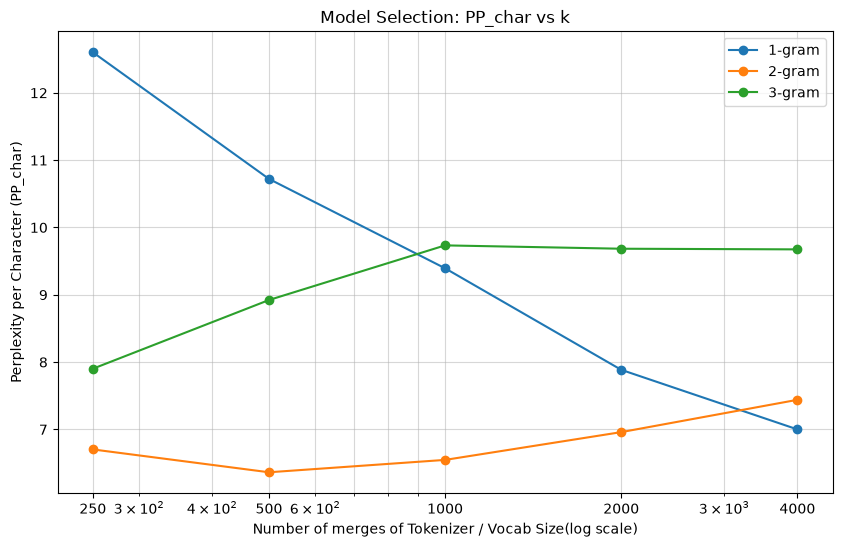


Best Combination: n*=2, k*=500
Test Perplexity (Best Model): PP=84.5009, PP_char=7.0679

Test perplexity for all n at k*=500:
n=1, k=500: PP=248.2711, PP_char=11.3656


n=2, k=500: PP=84.5009, PP_char=7.0679
n=3, k=500: PP=197.0355, PP_char=10.2647


In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from bpe import BPETokenizer, normalize

ks = [250, 500, 1000, 2000, 4000]
ns = [1,2,3]
results = [] # list to create the table

# get char counts for PP_char
C_val = len(val_text)
C_test = len(test_text)

# Grid Search
for k in ks:
    # train bpe for this k
    current_tok = BPETokenizer(num_merges=k, end_of_word="</w>", strategy="clean")
    current_tok.train(normalize(train_text, "clean"))
    
    # add special tokens to vocab
    current_tok.vocab["<bos>"] = len(current_tok.vocab)
    current_tok.vocab["<eos>"] = len(current_tok.vocab)
    V = len(current_tok.vocab)
    
    for n in ns:
        # encode the special tokens for each n
        def fast_encode(lines, tokenizer, n_val):
            bos_id = tokenizer.vocab["<bos>"]
            eos_id = tokenizer.vocab["<eos>"]
            return [[bos_id]*(n_val-1) + tokenizer.encode(l, count_unk=False) + [eos_id] for l in lines]
        
        curr_train_ids = fast_encode(train_lines, current_tok, n)
        curr_val_ids = fast_encode(val_lines, current_tok, n)
        
        # train n-Gram
        model = NGramLM(n=n, vocab_size=V)
        model.fit(curr_train_ids)
        
        # compute perplexity on validation set
        pp, pp_char = perplexity(model, curr_val_ids, C_val)
        results.append({"k": k, "n": n, "PP": pp, "PP_char": pp_char, "tokenizer": current_tok, "model": model})
        print(f"Fertig: k={k}, n={n} -> PP_char={pp_char:.4f}")

# make results table
df = pd.DataFrame(results)
pivot_df = df.pivot(index="n", columns="k", values="PP_char")
print("\nValidation PP_char Grid:")
print(pivot_df)

# Plot
plt.figure(figsize=(10, 6))
for n in ns:
    subset = df[df["n"] == n]
    plt.plot(subset["k"], subset["PP_char"], marker='o', label=f"{n}-gram")

plt.xscale('log')
plt.xticks(ks, ks)
plt.xlabel("Number of merges of Tokenizer / Vocab Size(log scale)")
plt.ylabel("Perplexity per Character (PP_char)")
plt.title("Model Selection: PP_char vs k")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

# choose best model 
best_row = df.loc[df["PP_char"].idxmin()]
n_star, k_star = best_row["n"], best_row["k"]
print(f"\nBest Combination: n*={n_star}, k*={k_star}")

# evaluate best tokenizer on test set
best_tokenizer = best_row["tokenizer"]
best_model = best_row["model"]
test_ids_final = [[best_tokenizer.vocab["<bos>"]]*(n_star-1) + 
                  best_tokenizer.encode(l, count_unk=False) + 
                  [best_tokenizer.vocab["<eos>"]] for l in test_lines]

pp_test, pp_char_test = perplexity(best_model, test_ids_final, C_test)
print(f"Test Perplexity (Best Model): PP={pp_test:.4f}, PP_char={pp_char_test:.4f}")

# evaluate the other two n values at k*
print(f"\nTest perplexity for all n at k*={k_star}:")

for n in [1, 2, 3]:
    row = next(
        row for row in results
        if row["n"] == n and row["k"] == k_star
    )

    tokenizer = row["tokenizer"]
    model = row["model"]

    test_ids = [
        [tokenizer.vocab["<bos>"]] * (n - 1)
        + tokenizer.encode(l, count_unk=False)
        + [tokenizer.vocab["<eos>"]]
        for l in test_lines
    ]

    pp, pp_char = perplexity(model, test_ids, C_test)

    print(f"n={n}, k={k_star}: PP={pp:.4f}, PP_char={pp_char:.4f}")

We see that the unigram continuously improves, though it starts with very high perplexity. The trigram interestingly gets worse with higher k but levels off at close to 10 whereas the bigram starts with very low perplexity but also gets worse with higher k. 
We can interpret this the following way: The additional context of the bigram is very helpful and improves the performance, but since the corpus is rather small trigram combinations might not be common enough, such that with the bigger context the model actually performs worse.
The same shows in the values for the test perplexity

### Task 5: Generation (20 points)

In [15]:
from evaluation import generate

In [16]:
output = generate(best_model, best_tokenizer, "clean", "Amen","argmax", 200, 0)
print(output)

Use the same three prompts for every mode. Generate ten
outputs per mode. Show them in the notebook. 


In [17]:
prompts = [
    "you",
    "the king",
    "shall I"
]

for prompt in prompts:
    print("\n" + "=" * 60)
    print("PROMPT:", prompt)

    for mode in ["argmax", "sample"]:
        print("\nMODE:", mode)
        mode = mode

        for i in range(10):
            text = generate(
                best_model,
                best_tokenizer,
                "clean",
                prompt,
                mode,
                max_tokens=200,
                seed=i
            )

            print(f"{i+1:2d}: {text}")


PROMPT: you

MODE: argmax
 1: have being
 2: have being
 3: have being
 4: have being
 5: have being
 6: have being
 7: have being
 8: have being
 9: have being
10: have being

MODE: sample
 1: shall we boght but men's acup el--bodeastity,--
 2: say. <unk>shapld a las, ow dy r self toes shall hatl romeo: ess naend now, oubansw:
 3: now's, worraore him that i minds and fawentful vien, thrie? whoters the tow's the dame fairglouce, of us doth he sinbut ents, shall make no grealy ren can subenetime
 4: shall we have saagaincome, youry! jour so.
 5: ivhearse, fore ent of nor'er it al to you,
 6: light;
 7: ted be d; n, sirdaer that he us:
 8: smoconcestime soit ionthough yorkeekarences ere priclofrienmaelther, f le richard iied to be buther?


 9: most lady m, part-thou that spit while hettle blowmade ch of gwarwicks at linansweey; fer with et er: molor;
10: aing it ontinghaveliven,

PROMPT: the king

MODE: argmax
 1: richard iii:
 2: richard iii:
 3: richard iii:
 4: richard iii:
 5: richard iii:
 6: richard iii:
 7: richard iii:
 8: richard iii:
 9: richard iii:
10: richard iii:

MODE: sample
 1: richard ius: gloucester: against deitacup el--bodeastity,--
 2: umdes<unk>shapld a las, ow dy r self toes shall hatl romeo: ess naend now, oubansw:
 3: corded hilory, wilor! what padisolyal prinpostais, y? whoters the tow's the dame fairglouce, of us doth he sinbut ents, shall make no grealy ren can subenetime
 4: richard let me thy know sir, to the ces d!
 5: stranger: sed old owaf'er it al to you,
 6: me auo t's him toyorkboth to ked? fahenry whaatorn he d. heart of a ls
 7: edward ow gloucester: tys, heat, your brotherwould will ly was
 8: est. ter: take julieountagonthough yorkeekarences ere priclofrienmaelther, f le richard i

 1: now she et p it sod,
 2: will der<unk>shapld a las, ow dy r self toes shall hatl romeo: ess naend now, oubansw:
 3: will bleone, ure, mual.
 4: marcharere one man too e to flad!
 5: cannot ongaffrilove,
 6: becanstresvidecordo you notreat, to give me on my brother t. do you that rifouse,
 7: am not ranct ruwhatain what safeelse broom place pragentvow gento, truquivery ed.
 8: kly fair
 9: corinorlord pauall as blirrutero:
10: aing it ontinghaveliven,


Then answer these two points in a short table:
how many argmax outputs fall into a loop, and how many sample outputs stop at <eos> before
the limit.

| Mode | Fall into loop | Stop before limit |
|---|---:|---:|
| Argmax | 10 (all for "Shall I") | 20 |
| Sample | 0 | 30 |
